# Curso de Algebra Lineal

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
A = np.array([[-1,3],[2,-2]])
A

array([[-1,  3],
       [ 2, -2]])

In [4]:
vector = np.array([[2],[1]])
vector

array([[2],
       [1]])

In [5]:
%run '/content/drive/MyDrive/Colab Notebooks/aux_functions.ipynb'

In [6]:
print(vector)
print(vector.flatten())

[[2]
 [1]]
[2 1]


In [7]:
print(A)
print(A.flatten())

[[-1  3]
 [ 2 -2]]
[-1  3  2 -2]


(-0.5, 2.0)

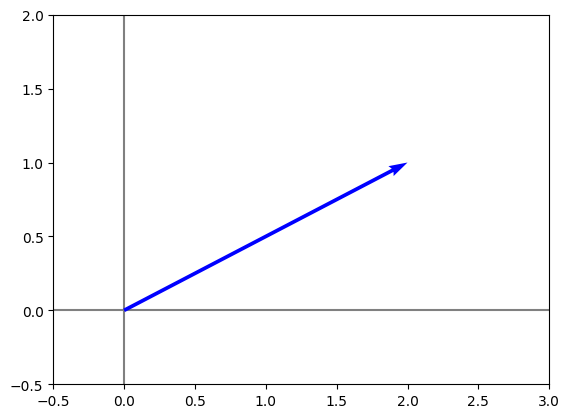

In [8]:
graficarVectores([vector.flatten()], cols = 'blue')

plt.xlim(-0.5,3)
plt.ylim(-0.5,2)

In [9]:
vector_t = A.dot(vector)
print(vector_t)

[[1]
 [2]]


(-0.5, 3.0)

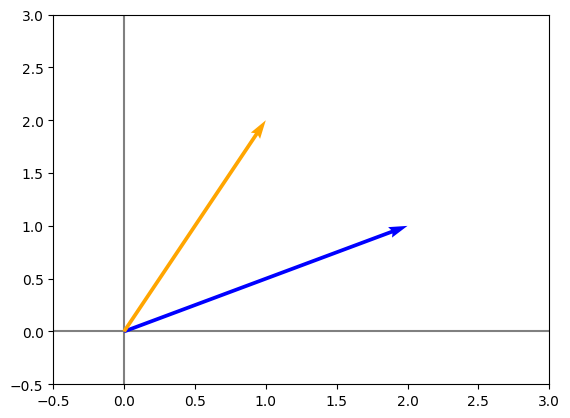

In [10]:
graficarVectores([vector.flatten(), vector_t.flatten()], cols = ['blue', 'orange'])

plt.xlim(-0.5,3)
plt.ylim(-0.5,3)

In [11]:
print(np.linalg.det(A))

-4.0


# Descomponer matrices
##Cuadradas



In [12]:
A = np.array([[3,2],[4,1]])
A

array([[3, 2],
       [4, 1]])

En la linea anterior tenemos nuestra matriz original.

In [13]:
autovalores, autovectores = np.linalg.eig(A)
autovalores

array([ 5., -1.])

In [14]:
autovectores

array([[ 0.70710678, -0.4472136 ],
       [ 0.70710678,  0.89442719]])

In [15]:
A_calc = autovectores.dot(np.diag(autovalores)).dot(np.linalg.inv(autovectores))
A_calc

array([[3., 2.],
       [4., 1.]])

En la celda anterior podemos ver como recuperamos la matriz original, conmbinando sus elementos descompuestos.

 -> ***A⋅v=λ⋅v***

## NO Cuadradas

Creamos la matriz 'A'

In [16]:
 A = np.array([[1,2,3],[3,4,5]])
 A

array([[1, 2, 3],
       [3, 4, 5]])

##  SVD (Singular Value Decomposition):

*   This works for any shape (square or rectangular).

*    It's like the "generalization" of eigenvalue decomposition.


*   Widely used in ML (PCA, LSA, compression, etc.)



In [17]:
U, D, V = np.linalg.svd(A)
U

array([[-0.46410668, -0.88577931],
       [-0.88577931,  0.46410668]])

In [18]:
print(np.diag(D))

[[7.97638869 0.        ]
 [0.         0.61418515]]


In [19]:
magicMatrix = np.array([[D[0],0,0],[0,D[1],0]])
magicMatrix

array([[7.97638869, 0.        , 0.        ],
       [0.        , 0.61418515, 0.        ]])

In [20]:
print(V)

[[-0.39133557 -0.5605708  -0.72980603]
 [ 0.8247362   0.13817999 -0.54837623]
 [ 0.40824829 -0.81649658  0.40824829]]


In [21]:
A_calc = U.dot(magicMatrix).dot(V)
A_calc

array([[1., 2., 3.],
       [3., 4., 5.]])

In [22]:
magicMatrix = np.concatenate((np.diag(D),np.zeros((2,1))), axis=1)
magicMatrix

array([[7.97638869, 0.        , 0.        ],
       [0.        , 0.61418515, 0.        ]])

In [23]:
A_calc = U.dot(magicMatrix).dot(V)
A_calc

array([[1., 2., 3.],
       [3., 4., 5.]])

# Las tres transformaciones

In [24]:
A = np.array([[3,7],[5,2]])
A

array([[3, 7],
       [5, 2]])

Circulo Unitario:


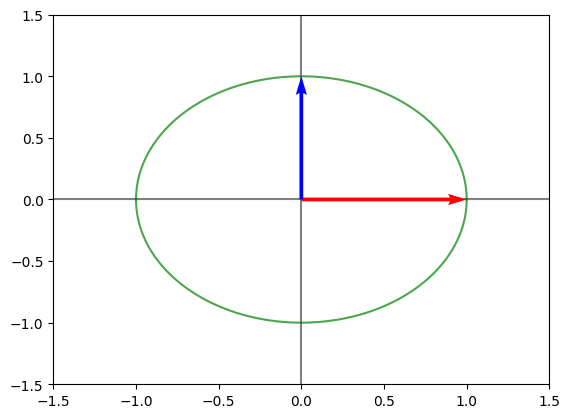

In [25]:
print('Circulo Unitario:')
graficarMatriz(np.eye(2))

plt.xlim(-1.5,1.5)
plt.ylim(-1.5,1.5)
plt.show()

In [26]:
A

array([[3, 7],
       [5, 2]])

Circulo Unitario:


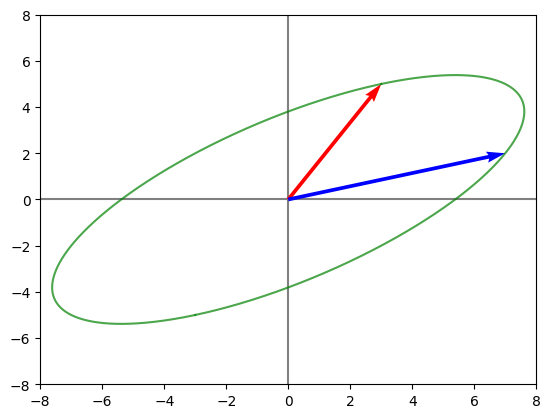

In [27]:
print('Circulo Unitario:')
graficarMatriz(A)

plt.xlim(-8,8)
plt.ylim(-8,8)
plt.show()

# Aplicacoin de las matrices D, V y U
## efecto en la transformacion


In [28]:
U, D, V = np.linalg.svd(A)
U

array([[-0.85065081, -0.52573111],
       [-0.52573111,  0.85065081]])

Circulo Unitario:


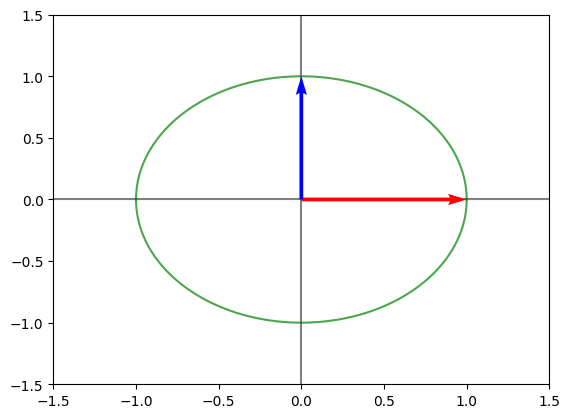

Primer Rotacion V:


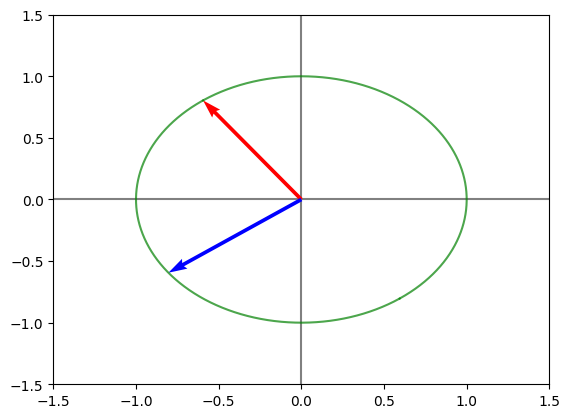

Escala (D):


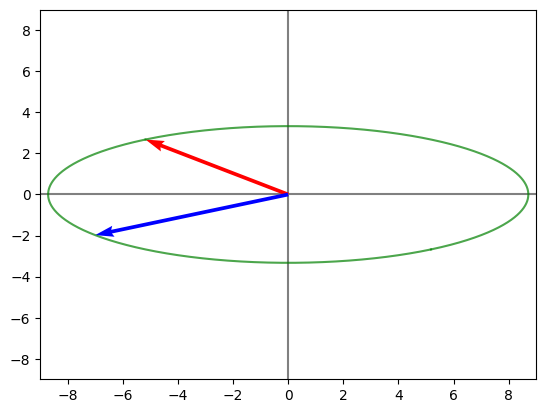

Segunda Rotacion U:


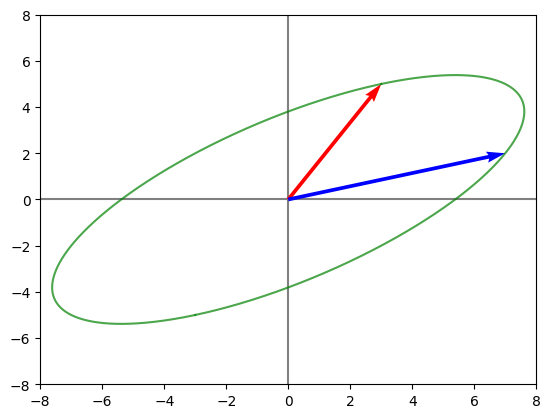

In [29]:
print('Circulo Unitario:')
graficarMatriz(np.eye(2))

plt.xlim(-1.5,1.5)
plt.ylim(-1.5,1.5)
plt.show()

print('Primer Rotacion V:')
graficarMatriz(V)

plt.xlim(-1.5,1.5)
plt.ylim(-1.5,1.5)
plt.show()


print('Escala (D):')
graficarMatriz(np.diag(D).dot(V))

plt.xlim(-9,9)
plt.ylim(-9,9)
plt.show()


print('Segunda Rotacion U:')
graficarMatriz(U.dot(np.diag(D).dot(V)))

plt.xlim(-8,8)
plt.ylim(-8,8)
plt.show()



# Interpretacion de los valores singulares

In [30]:
A = np.array([[3,7],[5,2]])
A

array([[3, 7],
       [5, 2]])

In [31]:
U, D, V = np.linalg.svd(A)
print(np.diag(D))

[[8.71337969 0.        ]
 [0.         3.32821489]]


In [32]:
print(D[0])
print(D[1])

8.7133796929634
3.3282148858288965


In [33]:
u1 = [D[0]*U[0,0],D[0]*U[0,1]]
v1 = [D[1]*U[1,0],D[1]*U[1,1]]

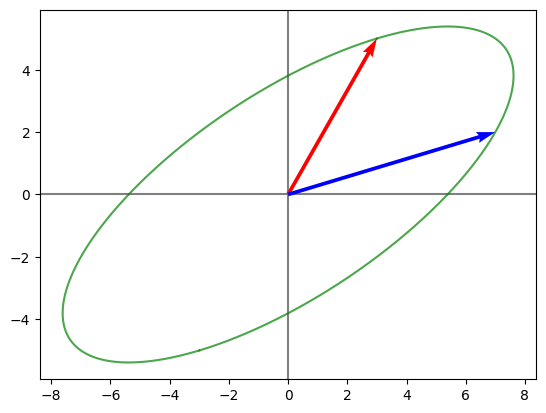

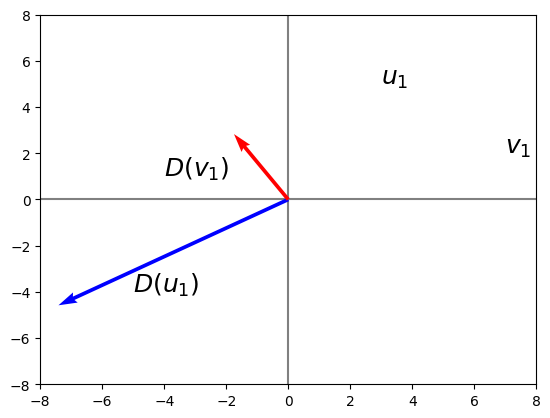

In [34]:
graficarMatriz(A)
graficarVectores([u1, v1], cols = ['blue', 'red'])

plt.text(3,5, r"$u_1$", size = 18)
plt.text(7,2, r"$v_1$", size = 18)

plt.text(-5,-4, r"$D(u_1)$", size = 18)
plt.text(-4,1, r"$D(v_1)$", size = 18)

plt.xlim(-8, 8)
plt.ylim(-8, 8)
plt.show()

# Una imagen es una matriz

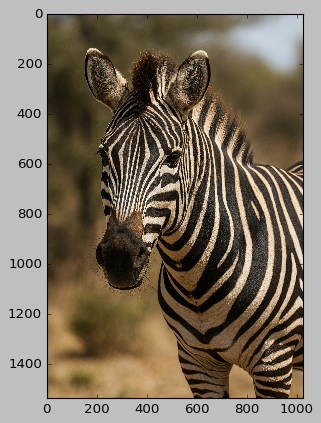

In [35]:
from PIL import Image
plt.style.use('classic')
image = Image.open('cute_zebra.png')
plt.imshow(image)
# plt.axis('off') -> this removes the axis for a cleaner look

In [36]:
image_gr = image.convert('LA')
print(image_gr)

<PIL.Image.Image image mode=LA size=1024x1536 at 0x7B7D305764D0>


In [37]:
image_mat = np.array(image_gr)
print(image_mat)

[[[102 255]
  [105 255]
  [103 255]
  ...
  [200 255]
  [200 255]
  [199 255]]

 [[ 99 255]
  [ 93 255]
  [105 255]
  ...
  [199 255]
  [201 255]
  [199 255]]

 [[ 98 255]
  [100 255]
  [102 255]
  ...
  [200 255]
  [201 255]
  [199 255]]

 ...

 [[154 255]
  [149 255]
  [151 255]
  ...
  [140 255]
  [142 255]
  [145 255]]

 [[151 255]
  [157 255]
  [153 255]
  ...
  [143 255]
  [148 255]
  [141 255]]

 [[152 255]
  [154 255]
  [151 255]
  ...
  [146 255]
  [143 255]
  [141 255]]]


In [38]:
image_mat.shape

(1536, 1024, 2)

In [39]:
image_mat = np.array(list(image_gr.getdata(band=0)), float)
print(image_mat)

[102. 105. 103. ... 146. 143. 141.]


In [40]:
image_mat.shape = (image_gr.size[1], image_gr.size[0])
print(image_mat)

[[102. 105. 103. ... 200. 200. 199.]
 [ 99.  93. 105. ... 199. 201. 199.]
 [ 98. 100. 102. ... 200. 201. 199.]
 ...
 [154. 149. 151. ... 140. 142. 145.]
 [151. 157. 153. ... 143. 148. 141.]
 [152. 154. 151. ... 146. 143. 141.]]


In [41]:
image_mat.shape

(1536, 1024)

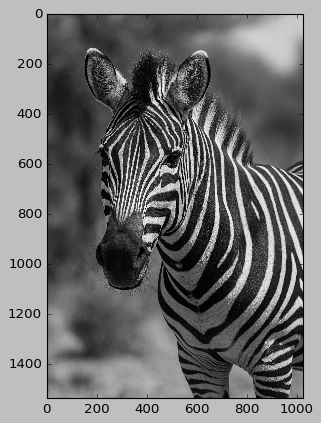

In [42]:
plt.imshow(image_mat, cmap='gray')
plt.show()

## Normalizando datos
En este paso podremos ver como se normalizan (hacen mas pequeños) los datos de la matriz.

In [43]:
img_mat2 = image_mat / 10
print(img_mat2)

[[10.2 10.5 10.3 ... 20.  20.  19.9]
 [ 9.9  9.3 10.5 ... 19.9 20.1 19.9]
 [ 9.8 10.  10.2 ... 20.  20.1 19.9]
 ...
 [15.4 14.9 15.1 ... 14.  14.2 14.5]
 [15.1 15.7 15.3 ... 14.3 14.8 14.1]
 [15.2 15.4 15.1 ... 14.6 14.3 14.1]]


Esto muestra como ha cambiado la imagen

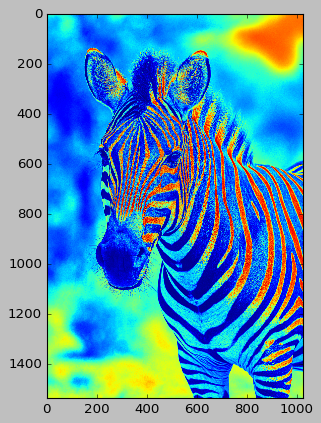

In [44]:
plt.imshow(img_mat2)
plt.show()

### Conservacion de la relacion entre datos
A pesar de haber sufrido un cambio, al poner la escala de grises, podemos notar como estos mantienen la relacion entre si, mejorando el procesamiento de datos y manteniendo el efectivo resultado de este.

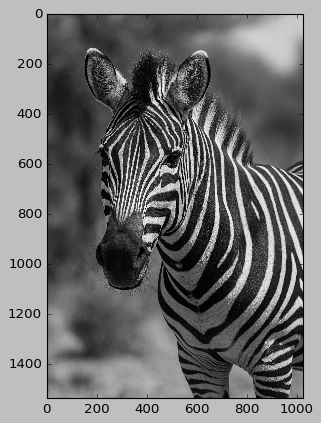

In [45]:
plt.imshow(img_mat2, cmap='gray')
plt.show()

# Aplicacion de SVD

In [46]:
image_mat # con la imagen convertida a matriz en escala de grices...

array([[102., 105., 103., ..., 200., 200., 199.],
       [ 99.,  93., 105., ..., 199., 201., 199.],
       [ 98., 100., 102., ..., 200., 201., 199.],
       ...,
       [154., 149., 151., ..., 140., 142., 145.],
       [151., 157., 153., ..., 143., 148., 141.],
       [152., 154., 151., ..., 146., 143., 141.]])

## Descomponemos la matriz utilizando SVD

In [47]:
U, D, V = np.linalg.svd(image_mat)

In [48]:
print(image_mat.shape)
print('u:', U.shape)
print('d:',D.shape)
print('v:',V.shape)

(1536, 1024)
u: (1536, 1536)
d: (1024,)
v: (1024, 1024)


In [49]:
image_recons = np.matrix(U[:,:1]) * np.diag(D[:1]) * np.matrix(V[:1,:])
print(image_recons)

[[ 97.58565529  97.15158429  97.21248274 ... 130.0222615  129.65721011
  129.3339473 ]
 [ 97.2934834   96.86071201  96.92142813 ... 129.63297426 129.26901584
  128.94672088]
 [ 97.18362158  96.75133887  96.81198643 ... 129.48659535 129.12304791
  128.80111687]
 ...
 [104.1131028  103.64999705 103.71496896 ... 138.71937467 138.32990521
  137.98501953]
 [104.31948973 103.85546595 103.92056665 ... 138.99436278 138.60412126
  138.2585519 ]
 [104.75669588 104.29072737 104.35610091 ... 139.57689238 139.18501535
  138.8379977 ]]


## 🧠 Plain-English Breakdown:
1. U[:, :1]
- This takes the first column of U.

- It's the main "output direction" the image gets stretched towards.

2. D[:1]
- This takes the largest singular value (σ₁).

- It tells us how much to stretch along that direction.

- np.diag(D[:1]) puts it into a diagonal matrix so it can be used in matrix multiplication.

3. V[:1, :]
- This takes the first row of V.

- It's the main "input direction" the image gets projected from.

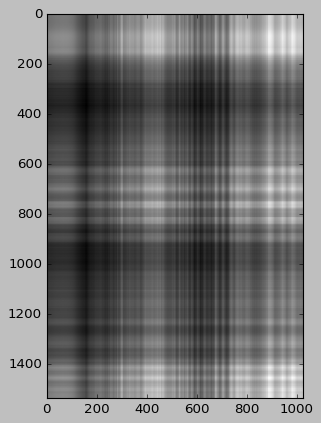

In [50]:
plt.imshow(image_recons, cmap='gray')
plt.show()

Rebuild the image using only the `5` most important pieces of information from the original. Show me what that version looks like in grayscale.

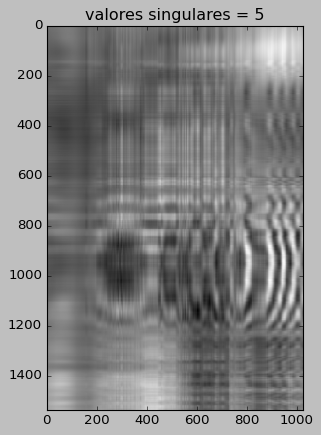

In [51]:
i = 5
image_recons = np.matrix(U[:,:i]) * np.diag(D[:i]) * np.matrix(V[:i,:])
plt.imshow(image_recons, cmap='gray')
plt.title(f"valores singulares = {i}")
plt.show()

Rebuild the image using only the `i` most important pieces of information from the original. Show me what that version looks like in grayscale.

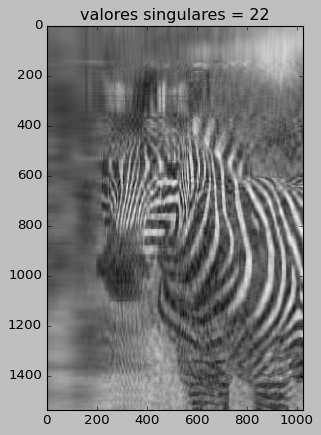

In [52]:
i = 22
image_recons = np.matrix(U[:,:i]) * np.diag(D[:i]) * np.matrix(V[:i,:])
plt.imshow(image_recons, cmap='gray')
plt.title(f"valores singulares = {i}")
plt.show()

# que es una pseudoinversa
## Moore Penrose & cómo calcularla

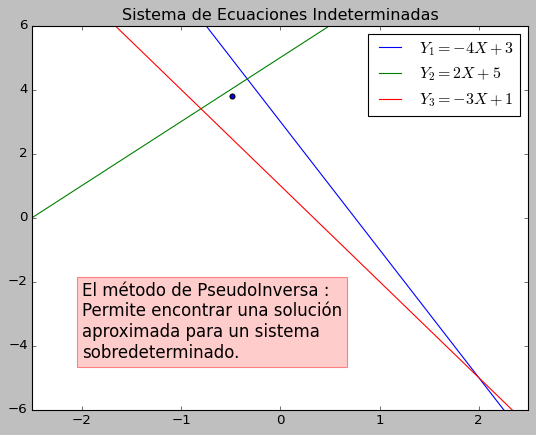

In [53]:
X = np.linspace(-5,5,1000)

# Texto
text = ("El método de PseudoInversa :\n"
"Permite encontrar una solución\n"
"aproximada para un sistema\n"
"sobredeterminado.")

# Sistema Sobredeterminado
Y1 = -4*X + 3
Y2 = 2*X + 5
Y3 = -3*X + 1

# Resultado
M2 = np.array([[4,1],[-2,1],[3,1]])
VS = np.array([[3,5,1]]).T
M2I = np.linalg.pinv(M2)
VR = M2I.dot(VS)

# Graficando Sistema de Ecuaciones
plt.title('Sistema de Ecuaciones Indeterminadas')
plt.plot(X,Y1, label= r'$Y_{1} = -4X + 3$')
plt.plot(X,Y2, label= r'$Y_{2} = 2X + 5$')
plt.plot(X,Y3, label= r'$Y_{3} = -3X + 1$')
plt.scatter(VR[0],VR[1])
plt.text(-2, -2, text, size=15,
         ha="left", va="top",
         bbox=dict(boxstyle="square",
                   ec=(1., 0.5, 0.5),
                   fc=(1., 0.8, 0.8),
                   )
         )

plt.xlim(-2.5,2.5)
plt.ylim(-6,6)
plt.legend()
plt.show()

# PCA
Principal Components Analysis

Generación de datos correlacionados

In [54]:
np.random.seed(42)
x = 3*np.random.rand(200)
y = x*20 + 2*np.random.rand(200)

x= x.reshape(200,1)
y= y.reshape(200,1)

xy = np.hstack([x,y])

Se generan dos arreglos de 200 valores cada uno:

- x: contiene valores aleatorios entre 0 y 3.

- y: se construye como una función lineal de x con pendiente 20, más un pequeño ruido aleatorio para introducir variabilidad.

El resultado es un conjunto de datos fuertemente correlacionados que simulan una distribución lineal con dispersión.

In [55]:
print("x values:", xy[:2, 0])
print("y values:", xy[:2, 1])

x values: [1.12362036 2.85214292]
y values: [23.75647042 57.21113831]


## Visualización de los puntos originales

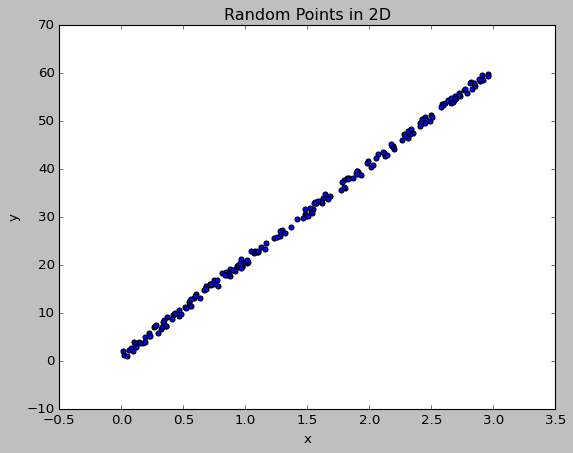

In [56]:
plt.scatter(xy[:,0], xy[:,1])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Random Points in 2D')
plt.show()

Se realiza una visualización de dispersión para observar la distribución de los datos generados. La gráfica muestra una nube de puntos alineada diagonalmente, lo que sugiere una fuerte correlación entre ambas variables.

In [57]:
xy.shape

(200, 2)

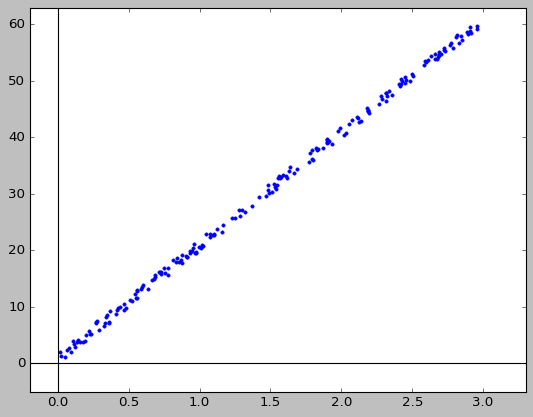

In [58]:
plt.plot(xy[:,0], xy[:,1], '.')
# Dibujar eje X (línea horizontal en y=0)
plt.axhline(0, color='black', linestyle='-', linewidth=1)

# Dibujar eje Y (línea vertical en x=0)
plt.axvline(0, color='black', linestyle='-', linewidth=1)
plt.xlim(-0.2, 3.3)
plt.ylim(-5, 63)
plt.show()

## Centrado de los datos

Antes de aplicar PCA, se centra el conjunto de datos restando la media de cada columna. Esto garantiza que la nube de puntos tenga como centro el origen (0, 0). Este paso es fundamental, ya que el análisis de componentes principales depende de la orientación relativa de los datos respecto al centroide.

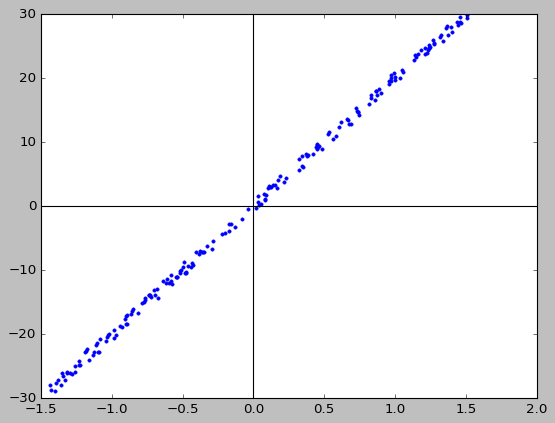

In [59]:
xy_centered = xy - np.mean(xy, axis=0)
plt.plot(xy_centered[:,0],xy_centered[:,1], '.')
# Dibujar eje X (línea horizontal en y=0)
plt.axhline(0, color='black', linestyle='-', linewidth=1)

# Dibujar eje Y (línea vertical en x=0)
plt.axvline(0, color='black', linestyle='-', linewidth=1)
plt.show()

Finalmente, se visualiza la nube de puntos ya centrada. Aunque los datos mantienen su forma y dirección general, ahora están centrados en torno al origen, lo que permite que los vectores principales (componentes) se calculen correctamente en los pasos posteriores del análisis.

In [60]:
autoval, autovec = np.linalg.eig(np.cov(xy_centered.T.dot(xy_centered)))
autovec

array([[-0.998753  , -0.04992445],
       [ 0.04992445, -0.998753  ]])

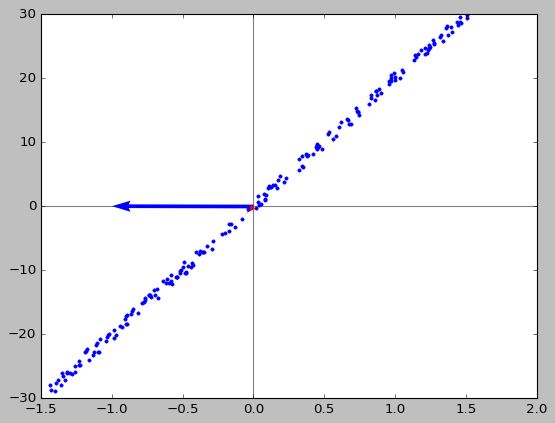

In [61]:
graficarVectores(autovec.T, cols = ['blue', 'red'])
plt.plot(xy_centered[:,0], xy_centered[:,1], '.')
plt.show()

## visualizando los vectores mejor:

aplanando verticalmente la nube de puntos. Todos los puntos en el eje y se hacen 10 veces más cercanos entre sí, sin alterar x.

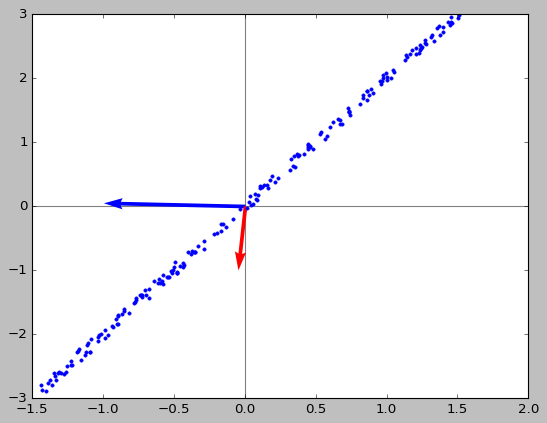

In [66]:
graficarVectores(autovec.T, cols = ['blue', 'red'])
plt.plot(xy_centered[:,0], xy_centered[:,1]/10, '.')
# plt.xlim(-3,3)
# plt.ylim(-3,3)
plt.show()

In [63]:
autoval

array([-2.38418579e-07,  1.75337921e+09])

## confirmacion con autoval
Podemos confirmar que es mayor el vector de rojo ya que en autoval nos lo muestra

In [64]:
xy_new = autovec.T.dot(xy_centered.T)

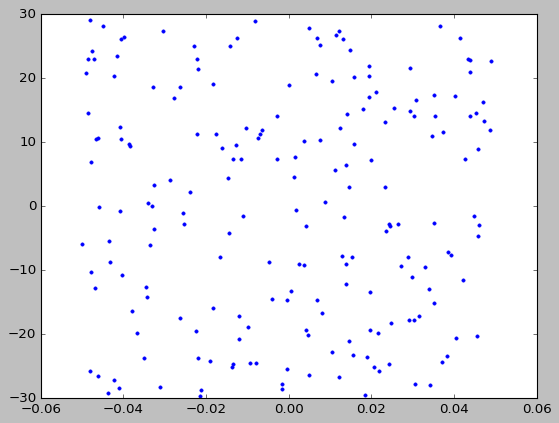

In [65]:
plt.plot(xy_new[0,:], xy_new[1,:], '.')
plt.show()

# Aplicando PCA a imagenes

In [67]:
# im = imageio

In [74]:
from sklearn.datasets import fetch_olivetti_faces
import pandas as pd

array([[ 79,  93, 106, ...,  94,  84,  77],
       [ 87, 103, 111, ...,  94,  86,  80],
       [ 87, 106, 114, ...,  96,  86,  75],
       ...,
       [ 54,  52,  56, ...,  38,  42,  44],
       [ 51,  53,  53, ...,  37,  41,  42],
       [ 51,  52,  51, ...,  38,  41,  40]], dtype=uint8)
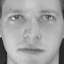

In [102]:
data = fetch_olivetti_faces()
im1 = data.images[0]
im1 = (im1 * 255).astype(np.uint8)
im1 = im1.astype(np.uint8)
im1

In [103]:
data.images[0]

array([[0.30991736, 0.3677686 , 0.41735536, ..., 0.37190083, 0.3305785 ,
        0.30578512],
       [0.3429752 , 0.40495867, 0.43801653, ..., 0.37190083, 0.338843  ,
        0.3140496 ],
       [0.3429752 , 0.41735536, 0.45041323, ..., 0.38016528, 0.338843  ,
        0.29752067],
       ...,
       [0.21487603, 0.20661157, 0.2231405 , ..., 0.15289256, 0.16528925,
        0.17355372],
       [0.20247933, 0.2107438 , 0.2107438 , ..., 0.14876033, 0.16115703,
        0.16528925],
       [0.20247933, 0.20661157, 0.20247933, ..., 0.15289256, 0.16115703,
        0.1570248 ]], dtype=float32)

In [106]:
print('Max original =', np.amax(im1))
print('Min original =', np.amin(im1))

Max original = 223
Min original = 21


In [108]:
im = im1 / 255
print('Max normilized =', np.amax(im))
print('Min normilized =', np.amin(im))

Max normilized = 0.8745098039215686
Min normilized = 0.08235294117647059


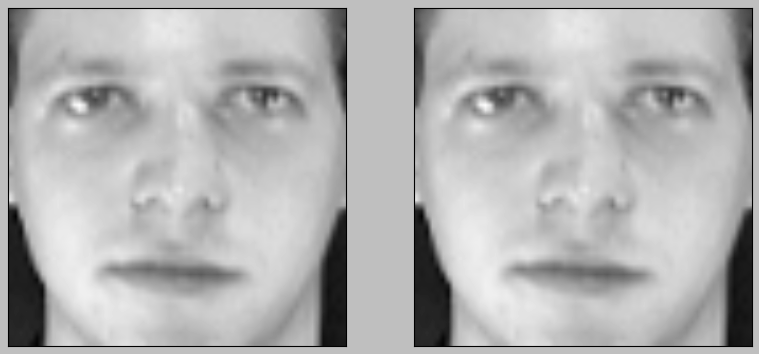

In [110]:
fix, ax = plt.subplots(1,2, figsize=(12,12),
                       subplot_kw={'xticks':[], 'yticks':[]})
ax[0].imshow(im1, cmap='gray')
ax[1].imshow(im, cmap='gray')
plt.show()

In [119]:
from glob import iglob
import imageio

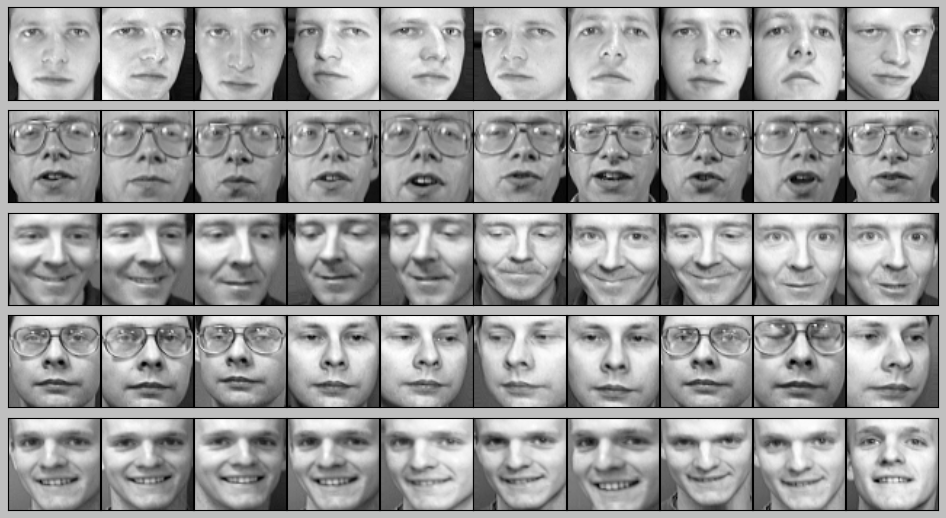

In [142]:
import sklearn.datasets
data = sklearn.datasets.fetch_olivetti_faces()
caras = pd.DataFrame([])

for i in range(50):
  cara = data.data[i].reshape(64,64)
  caraa = pd.Series(cara.flatten(), name=i)
  caras = pd.concat([caras, caraa], axis=1)

caras = caras.T

fig, axes = plt.subplots(5,10, figsize=(15,8),
                         subplot_kw = {'xticks': [], 'yticks': [],},
                         gridspec_kw = dict(hspace = 0.01, wspace=0.01))

for i, ax in enumerate(axes.flat):
  ax.imshow(caras.iloc[i].values.reshape(64,64),cmap='gray')

In [140]:
data

{'data': array([[0.30991736, 0.3677686 , 0.41735536, ..., 0.15289256, 0.16115703,
         0.1570248 ],
        [0.45454547, 0.47107437, 0.5123967 , ..., 0.15289256, 0.15289256,
         0.15289256],
        [0.3181818 , 0.40082645, 0.49173555, ..., 0.14049587, 0.14876033,
         0.15289256],
        ...,
        [0.5       , 0.53305787, 0.607438  , ..., 0.17768595, 0.14876033,
         0.19008264],
        [0.21487603, 0.21900827, 0.21900827, ..., 0.57438016, 0.59090906,
         0.60330576],
        [0.5165289 , 0.46280992, 0.28099173, ..., 0.35950413, 0.3553719 ,
         0.38429752]], dtype=float32),
 'images': array([[[0.30991736, 0.3677686 , 0.41735536, ..., 0.37190083,
          0.3305785 , 0.30578512],
         [0.3429752 , 0.40495867, 0.43801653, ..., 0.37190083,
          0.338843  , 0.3140496 ],
         [0.3429752 , 0.41735536, 0.45041323, ..., 0.38016528,
          0.338843  , 0.29752067],
         ...,
         [0.21487603, 0.20661157, 0.2231405 , ..., 0.15289256,
     

In [143]:
data['target'].shape

(400,)

In [146]:
a = np.array([[3, 4],[3, 2]])
a

array([[3, 4],
       [3, 2]])

In [147]:
auv, auvec = np.linalg.eig(a)
print(auv)
print(auvec)

[ 6. -1.]
[[ 0.8        -0.70710678]
 [ 0.6         0.70710678]]
